In [1]:
import sys
sys.path.append('../datasets')
sys.path.append('../algorithms')
sys.path.append('../test')


import torch

import matplotlib.pyplot as plt
from pansharpening_static import PANHandler
from load_pavia import load_pavia
from pan_ctv import PANTVCTV
from torchvision import transforms
from math import sqrt
from PIL import Image , ImageFont,ImageDraw

/home/y/Documents/projects/python/spectral-spatial/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
/home/y/Documents/projects/python/spectral-spatial/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define device (default is "cpu")
device = "cpu" 

    # Define dtype
dtype = torch.float64
crop_size = 256
    # Define random seed
seed = 42
torch.manual_seed(seed)

    # Define data path
data_path = '../../data/PaviaU.mat'

rgb = [29,19,9]

In [3]:
hsi_data = load_pavia(data_path)
_, b, h,w = hsi_data.shape
PAN = PANHandler(nband=b, 
                 size=(h,w),
                 scale=4,
                 sigma=1,
                 noise_level=0.1,
                 seed=42 
                 )

Loaded HSI data with shape: torch.Size([1, 103, 610, 340])
Number of spectral bands: 103


In [4]:
# Matrice de transformation
X = hsi_data

Y_H = PAN.simulate_low_res_hsi(X)  
Y_M = PAN.get_panchromatic(X)

In [5]:
A,A_adj, R, R_adj = PAN.get_operators()

solver_gp = PANTVCTV(
    A=A,
    Aadj=A_adj,
    spectral_op = R,
    spectral_op_t = R_adj,
    max_iter=50,
    lmbda=0.2,
    lmbda_m=2,
    tol=1e-7,
    scale=PAN.scale,
    p = float('inf'),
    q = 1,
    r = 1,
    verbose=True,
    
)

In [6]:
U_gp, costs_gp = solver_gp(Y_H, Y_M)

2025-07-16 19:00:06,955 - INFO - 
Début de l'optimisation:
2025-07-16 19:00:06,956 - INFO - It    | Coût total   | Data H       | Data M       | TV           | ΔU          
2025-07-16 19:00:06,956 - INFO - --------------------------------------------------------------------------------
2025-07-16 19:00:08,232 - INFO - 0     | 1.783e+12    | 1.386e+12    | 3.967e+11    | 2.498e+05    | 2.386e-01   
2025-07-16 19:00:21,497 - INFO - 10    | 1.306e+12    | 1.014e+12    | 2.926e+11    | 9.587e+05    | 6.319e-02   
2025-07-16 19:00:35,201 - INFO - 20    | 9.598e+11    | 7.428e+11    | 2.170e+11    | 1.636e+06    | 3.393e-02   
2025-07-16 19:00:49,910 - INFO - 30    | 7.075e+11    | 5.454e+11    | 1.621e+11    | 2.275e+06    | 2.201e-02   
2025-07-16 19:01:05,221 - INFO - 40    | 5.234e+11    | 4.014e+11    | 1.221e+11    | 2.877e+06    | 1.560e-02   
2025-07-16 19:01:18,823 - INFO - 49    | 4.006e+11    | 3.053e+11    | 9.531e+10    | 3.391e+06    | 1.198e-02   


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [168.42548..4302.7837].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [66.07808..2464.9795].


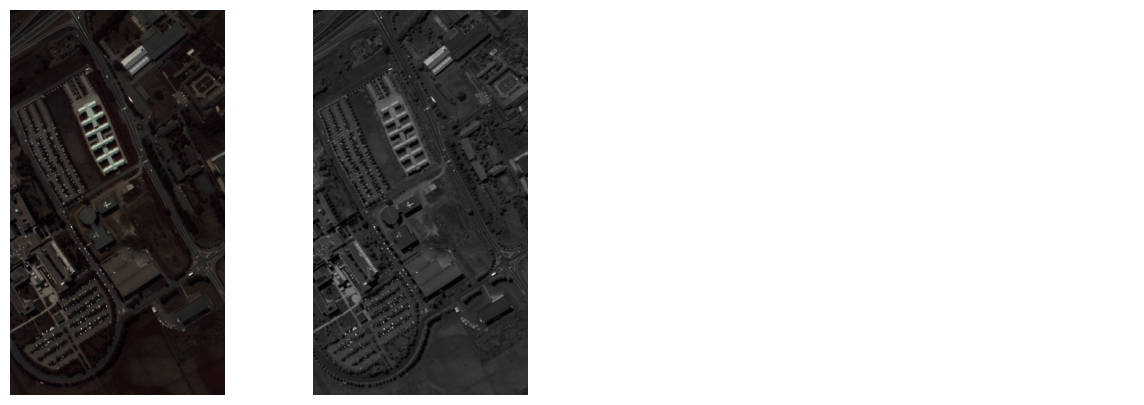

In [ ]:

x_rgb = X[0, rgb,...].cpu().numpy().transpose(1, 2, 0)
x_rgb = (x_rgb - x_rgb.min())/(x_rgb.max() - x_rgb.min())

y_rgb = Y_H[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
y_rgb = (y_rgb - y_rgb.min())/(y_rgb.max() - y_rgb.min())

z_rgb = U_gp[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
z_rgb = (z_rgb - z_rgb.min())/(z_rgb.max() - z_rgb.min())

plt.figure(figsize=(15, 5))
plt.subplot(141)
plt.imshow(x_rgb)
# plt.title('RGB')
plt.axis('off')

plt.subplot(142)
plt.imshow(Y_M[0, 0, ...].cpu().numpy(), cmap='gray')
# plt.title('Panchromatic')
plt.axis('off')

plt.subplot(143)
plt.imshow(y_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

plt.subplot(144)
plt.imshow(z_rgb)
# plt.title('Noisy RGB')=4
plt.axis('off')

plt.show()

Dimensions vérifiées: iterations (50,), cout_total 50


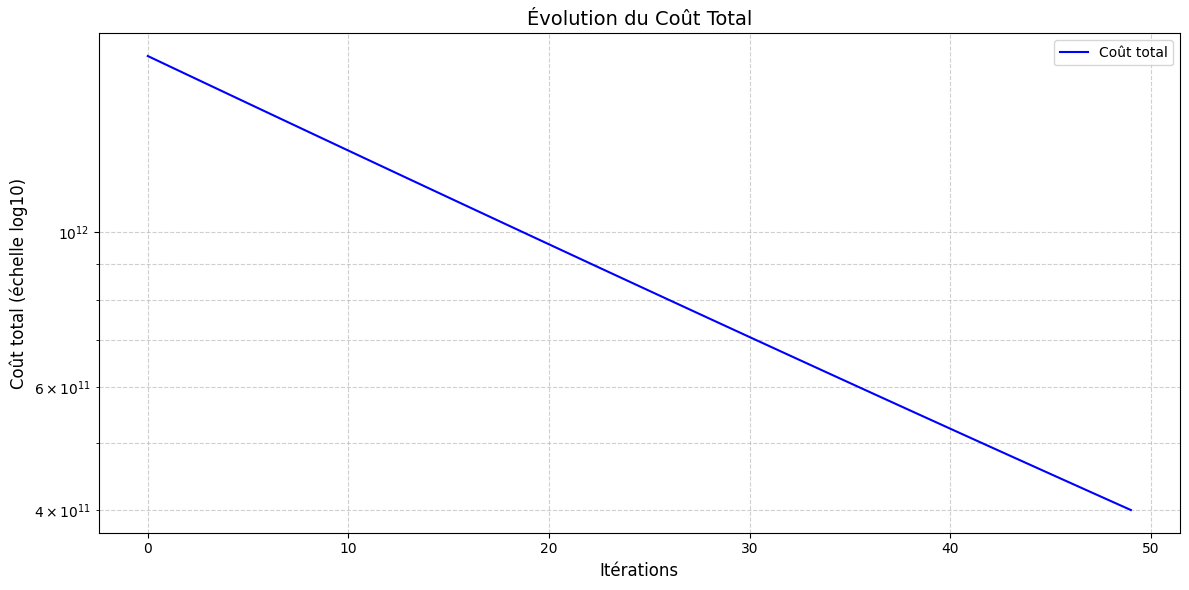

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Données d'exemple (à adapter avec vos données réelles)
cout_total = costs_gp

# Création du vecteur d'itérations de même longueur que cout_total
iterations = np.arange(0, len(cout_total))  # Pas de 10 entre les mesures

# Vérification des dimensions
print(f"Dimensions vérifiées: iterations {iterations.shape}, cout_total {len(cout_total)}")

# Création du graphique
plt.figure(figsize=(12, 6))
plt.semilogy(iterations, cout_total, 'b-', linewidth=1.5, label='Coût total')

# Personnalisation
plt.xlabel('Itérations', fontsize=12)
plt.ylabel('Coût total (échelle log10)', fontsize=12)
plt.title('Évolution du Coût Total', fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.6)

# Affichage
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
import torch
from torchvision import transforms
from PIL import Image
to_pil = transforms.ToPILImage()

In [32]:
image1 = to_pil(x_rgb)
image1.save('image1.png')

In [33]:
image2 = to_pil(Y_M[0, 0, ...])
image2.save('image2.png')

In [34]:
image3 = to_pil(y_rgb)
image3.save('image3.png')

In [35]:
image4 = to_pil(z_rgb)
image4.save('image4.png')